In [1]:
# Deep SVDD for Fraud Detection
# One-Class Deep Support Vector Data Description
# Full implementation with Cost-Sensitive Evaluation and Error Analysis

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    average_precision_score, roc_auc_score, 
    precision_recall_curve, precision_score, 
    recall_score, f1_score
)

try:
    current_dir = Path.cwd()
    if (current_dir / 'src').exists():
        PROJECT_ROOT = current_dir
    elif (current_dir.parent / 'src').exists():
        PROJECT_ROOT = current_dir.parent
    else:
        PROJECT_ROOT = Path.cwd().parent
except Exception:
    PROJECT_ROOT = Path.cwd()

print(f"Project root: {PROJECT_ROOT}")

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def load_processed_data(dataset='ieee'):
    data_dir = PROJECT_ROOT / 'data' / 'processed'
    train = pd.read_parquet(data_dir / f'{dataset}_train.parquet')
    test = pd.read_parquet(data_dir / f'{dataset}_test.parquet')
    with open(data_dir / 'dataset_info.json', 'r') as f:
        info = json.load(f)
    raw_cols = info[dataset]['raw_features']
    eng_cols = info[dataset]['engineered_features']
    all_cols = raw_cols + eng_cols
    return train, test, raw_cols, eng_cols, all_cols

train_ieee, test_ieee, raw_cols, eng_cols, all_cols = load_processed_data('ieee')

print(f"Total features: {len(all_cols)}")
print(f"Train shape: {train_ieee.shape}")
print(f"Test shape: {test_ieee.shape}")
print(f"Train fraud rate: {train_ieee['isFraud'].mean():.4f}")
print(f"Test fraud rate: {test_ieee['isFraud'].mean():.4f}")

# ============================================================
# 1. Feature Preparation
# ============================================================

X_train_raw = train_ieee[all_cols].values
X_test_raw = test_ieee[all_cols].values
y_train = train_ieee['isFraud'].values
y_test = test_ieee['isFraud'].values

print(f"\nX_train shape: {X_train_raw.shape}")
print(f"X_test shape: {X_test_raw.shape}")

if np.isnan(X_train_raw).sum() > 0:
    print(f"Filling {np.isnan(X_train_raw).sum()} missing values...")
    for i in range(X_train_raw.shape[1]):
        col_median = np.nanmedian(X_train_raw[:, i])
        X_train_raw[np.isnan(X_train_raw[:, i]), i] = col_median
        X_test_raw[np.isnan(X_test_raw[:, i]), i] = col_median

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"X_train shape after scaling: {X_train.shape}")
print(f"X_test shape after scaling: {X_test.shape}")



Project root: /Users/mac/Desktop/DSS5104_Assignment2
Using device: cpu
Total features: 64
Train shape: (472432, 470)
Test shape: (118108, 470)
Train fraud rate: 0.0351
Test fraud rate: 0.0344

X_train shape: (472432, 64)
X_test shape: (118108, 64)
Filling 3433954 missing values...
X_train shape after scaling: (472432, 64)
X_test shape after scaling: (118108, 64)


In [2]:
# 2. Deep SVDD Model

class ImprovedDeepSVDDNetwork(nn.Module):
    def __init__(self, input_dim, rep_dim=8):
        super(ImprovedDeepSVDDNetwork, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(32, rep_dim)
        )
    
    def forward(self, x):
        return self.encoder(x)


class OptimizedDeepSVDD:
    def __init__(self, input_dim, rep_dim=8, nu=0.05, lr=0.0005):
        self.net = ImprovedDeepSVDDNetwork(input_dim, rep_dim).to(device)
        self.rep_dim = rep_dim
        self.nu = nu
        self.lr = lr
        self.c = None
    
    def _init_center(self, dataloader):
        self.net.eval()
        embeddings = []
        with torch.no_grad():
            for batch_X, _ in dataloader:
                batch_X = batch_X.to(device)
                z = self.net(batch_X)
                embeddings.append(z)
        embeddings = torch.cat(embeddings, dim=0)
        self.c = torch.mean(embeddings, dim=0)
    
    def fit(self, X_train, y_train=None, epochs=150, batch_size=2048, verbose=True):
        normal_idx = (y_train == 0)
        X_normal = X_train[normal_idx]
        print(f"Training on {len(X_normal):,} normal samples")
        
        if len(X_normal) > 100000:
            idx = np.random.choice(len(X_normal), 100000, replace=False)
            X_normal = X_normal[idx]
            print(f"Sampled to {len(X_normal):,} normal samples")
        
        X_tensor = torch.FloatTensor(X_normal).to(device)
        dataset = TensorDataset(X_tensor, X_tensor)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        self._init_center(dataloader)
        print(f"Center initialized (dim={self.rep_dim})")
        
        optimizer = optim.Adam(self.net.parameters(), lr=self.lr, weight_decay=1e-6)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        
        train_losses = []
        best_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(epochs):
            self.net.train()
            epoch_loss = 0
            for batch_X, _ in dataloader:
                optimizer.zero_grad()
                z = self.net(batch_X)
                loss = torch.mean(torch.sum((z - self.c) ** 2, dim=1))
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * batch_X.size(0)
            
            epoch_loss /= len(X_normal)
            train_losses.append(epoch_loss)
            
            scheduler.step()
            
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                patience_counter = 0
                best_state = self.net.state_dict().copy()
            else:
                patience_counter += 1
            
            if patience_counter >= 30:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1}")
                break
            
            if verbose and (epoch + 1) % 20 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.6f}")
        
        self.net.load_state_dict(best_state)
        return train_losses
    
    def predict_anomaly_scores(self, X):
        X_tensor = torch.FloatTensor(X).to(device)
        self.net.eval()
        scores = []
        batch_size = 4096
        for i in range(0, len(X_tensor), batch_size):
            batch = X_tensor[i:i+batch_size]
            with torch.no_grad():
                z = self.net(batch)
                batch_scores = torch.sum((z - self.c) ** 2, dim=1)
                scores.append(batch_scores.cpu().numpy())
        return np.concatenate(scores)
    
    def get_latent(self, X):
        X_tensor = torch.FloatTensor(X).to(device)
        self.net.eval()
        with torch.no_grad():
            return self.net(X_tensor).cpu().numpy()


class EnsembleDeepSVDD:
    def __init__(self, input_dim, rep_dims=[4, 8, 16]):
        self.rep_dims = rep_dims
        self.models = []
        self.input_dim = input_dim
    
    def fit(self, X_train, y_train, epochs=150, batch_size=2048, verbose=True):
        for i, rep_dim in enumerate(self.rep_dims):
            print(f"\nTraining model {i+1}/{len(self.rep_dims)} with rep_dim={rep_dim}")
            model = OptimizedDeepSVDD(self.input_dim, rep_dim=rep_dim, nu=0.05, lr=0.0005)
            model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=verbose)
            self.models.append(model)
        return self
    
    def predict_anomaly_scores(self, X):
        all_scores = []
        for model in self.models:
            scores = model.predict_anomaly_scores(X)
            all_scores.append(scores)
        scores = np.mean(all_scores, axis=0)
        return (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
    
    def get_latent_representations(self, X, model_idx=0):
        return self.models[model_idx].get_latent(X)


In [3]:
# 3. Train Deep SVDD

input_dim = X_train.shape[1]
print(f"\nInput dimension: {input_dim}")

print("\n" + "="*60)
print("Training Ensemble Deep SVDD (Optimized)")
print("="*60)

ensemble_svdd = EnsembleDeepSVDD(input_dim, rep_dims=[4, 8, 16])
ensemble_svdd.fit(X_train, y_train, epochs=150, batch_size=2048, verbose=True)

test_scores = ensemble_svdd.predict_anomaly_scores(X_test)

auprc = average_precision_score(y_test, test_scores)
roc_auc = roc_auc_score(y_test, test_scores)

print(f"\nTest Results (Deep SVDD):")
print(f"  AUPRC: {auprc:.4f}")
print(f"  ROC AUC: {roc_auc:.4f}")




Input dimension: 64

Training Ensemble Deep SVDD (Optimized)

Training model 1/3 with rep_dim=4
Training on 455,833 normal samples
Sampled to 100,000 normal samples
Center initialized (dim=4)
Epoch 20/150, Loss: 0.001319
Epoch 40/150, Loss: 0.000058
Epoch 60/150, Loss: 0.000013
Epoch 80/150, Loss: 0.000004
Epoch 100/150, Loss: 0.000003
Epoch 120/150, Loss: 0.000002
Epoch 140/150, Loss: 0.000001

Training model 2/3 with rep_dim=8
Training on 455,833 normal samples
Sampled to 100,000 normal samples
Center initialized (dim=8)
Epoch 20/150, Loss: 0.000503
Epoch 40/150, Loss: 0.000250
Epoch 60/150, Loss: 0.000023
Epoch 80/150, Loss: 0.000001
Epoch 100/150, Loss: 0.000011
Epoch 120/150, Loss: 0.000005
Epoch 140/150, Loss: 0.000000

Training model 3/3 with rep_dim=16
Training on 455,833 normal samples
Sampled to 100,000 normal samples
Center initialized (dim=16)
Epoch 20/150, Loss: 0.000323
Epoch 40/150, Loss: 0.000029
Epoch 60/150, Loss: 0.000013
Epoch 80/150, Loss: 0.000026
Epoch 100/150, 

In [4]:

# 4. Cost-Sensitive Evaluation

def find_cost_optimal_threshold(y_true, y_scores, fn_cost=500, fp_cost=2):
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    costs = []
    f1_scores = []
    
    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        total_cost = fn * fn_cost + fp * fp_cost
        costs.append(total_cost)
        p = tp / (tp + fp + 1e-9)
        r = tp / (tp + fn + 1e-9)
        f1_scores.append(2 * p * r / (p + r + 1e-9) if (p + r) > 0 else 0)
    
    best_idx = np.argmin(costs)
    best_threshold = thresholds[best_idx]
    min_cost = costs[best_idx]
    f1_best_idx = np.argmax(f1_scores)
    f1_optimal_threshold = thresholds[f1_best_idx]
    
    return best_threshold, min_cost, f1_optimal_threshold, thresholds, costs, f1_scores

cost_threshold, min_cost, f1_threshold, thresholds, costs, f1_scores = find_cost_optimal_threshold(
    y_test, test_scores, fn_cost=500, fp_cost=2
)

print("\n" + "="*60)
print("Cost-Sensitive Evaluation (FN=$500, FP=$2)")
print("="*60)
print(f"\nDeep SVDD:")
print(f"  Cost-optimal threshold: {cost_threshold:.4f}")
print(f"  F1-optimal threshold: {f1_threshold:.4f}")
print(f"  Minimum total cost: ${min_cost:,.2f}")
print(f"  Difference (Cost vs F1): {abs(cost_threshold - f1_threshold):.4f}")







Cost-Sensitive Evaluation (FN=$500, FP=$2)

Deep SVDD:
  Cost-optimal threshold: 0.0000
  F1-optimal threshold: 0.0002
  Minimum total cost: $228,068.00
  Difference (Cost vs F1): 0.0002


In [5]:
# 5. Evaluation at Cost-Optimal Threshold

y_pred_optimal = (test_scores >= cost_threshold).astype(int)

precision_opt = precision_score(y_test, y_pred_optimal)
recall_opt = recall_score(y_test, y_pred_optimal)
f1_opt = f1_score(y_test, y_pred_optimal)

print("\n" + "="*60)
print(f"Evaluation at Cost-Optimal Threshold ({cost_threshold:.4f})")
print("="*60)
print(f"  AUPRC: {auprc:.4f}")
print(f"  Precision: {precision_opt:.4f}")
print(f"  Recall: {recall_opt:.4f}")
print(f"  F1: {f1_opt:.4f}")



Evaluation at Cost-Optimal Threshold (0.0000)
  AUPRC: 0.0453
  Precision: 0.0344
  Recall: 1.0000
  F1: 0.0665


In [6]:
# 6. Error Analysis

print("\n" + "="*60)
print("Error Analysis - Deep SVDD")
print("="*60)

fp_idx = np.where((y_test == 0) & (y_pred_optimal == 1))[0]
fn_idx = np.where((y_test == 1) & (y_pred_optimal == 0))[0]
tp_idx = np.where((y_test == 1) & (y_pred_optimal == 1))[0]

print(f"False Positives (Normal flagged as Fraud): {len(fp_idx)}")
print(f"False Negatives (Fraud missed): {len(fn_idx)}")
print(f"True Positives (Fraud caught): {len(tp_idx)}")

print("\n--- False Positives Analysis (First 10 samples) ---")
if len(fp_idx) > 0:
    sample_fp = test_ieee.iloc[fp_idx[:min(10, len(fp_idx))]]
    if 'TransactionAmt' in sample_fp.columns:
        print(f"Transaction amounts: min=${sample_fp['TransactionAmt'].min():.2f}, "
              f"max=${sample_fp['TransactionAmt'].max():.2f}, "
              f"mean=${sample_fp['TransactionAmt'].mean():.2f}")

print("\n--- False Negatives Analysis (First 10 samples) ---")
if len(fn_idx) > 0:
    sample_fn = test_ieee.iloc[fn_idx[:min(10, len(fn_idx))]]
    if 'TransactionAmt' in sample_fn.columns:
        print(f"Transaction amounts: min=${sample_fn['TransactionAmt'].min():.2f}, "
              f"max=${sample_fn['TransactionAmt'].max():.2f}, "
              f"mean=${sample_fn['TransactionAmt'].mean():.2f}")



Error Analysis - Deep SVDD
False Positives (Normal flagged as Fraud): 114034
False Negatives (Fraud missed): 0
True Positives (Fraud caught): 4064

--- False Positives Analysis (First 10 samples) ---
Transaction amounts: min=$23.36, max=$326.29, mean=$87.73

--- False Negatives Analysis (First 10 samples) ---


In [7]:
# 7. Latent Space Visualization

print("\n" + "="*60)
print("Latent Space Visualization")
print("="*60)

sample_size = 2000
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), sample_size, replace=False)
X_sample = X_test[sample_idx]
y_sample = y_test[sample_idx]

latent = ensemble_svdd.get_latent_representations(X_sample, model_idx=0)

pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent)


Latent Space Visualization


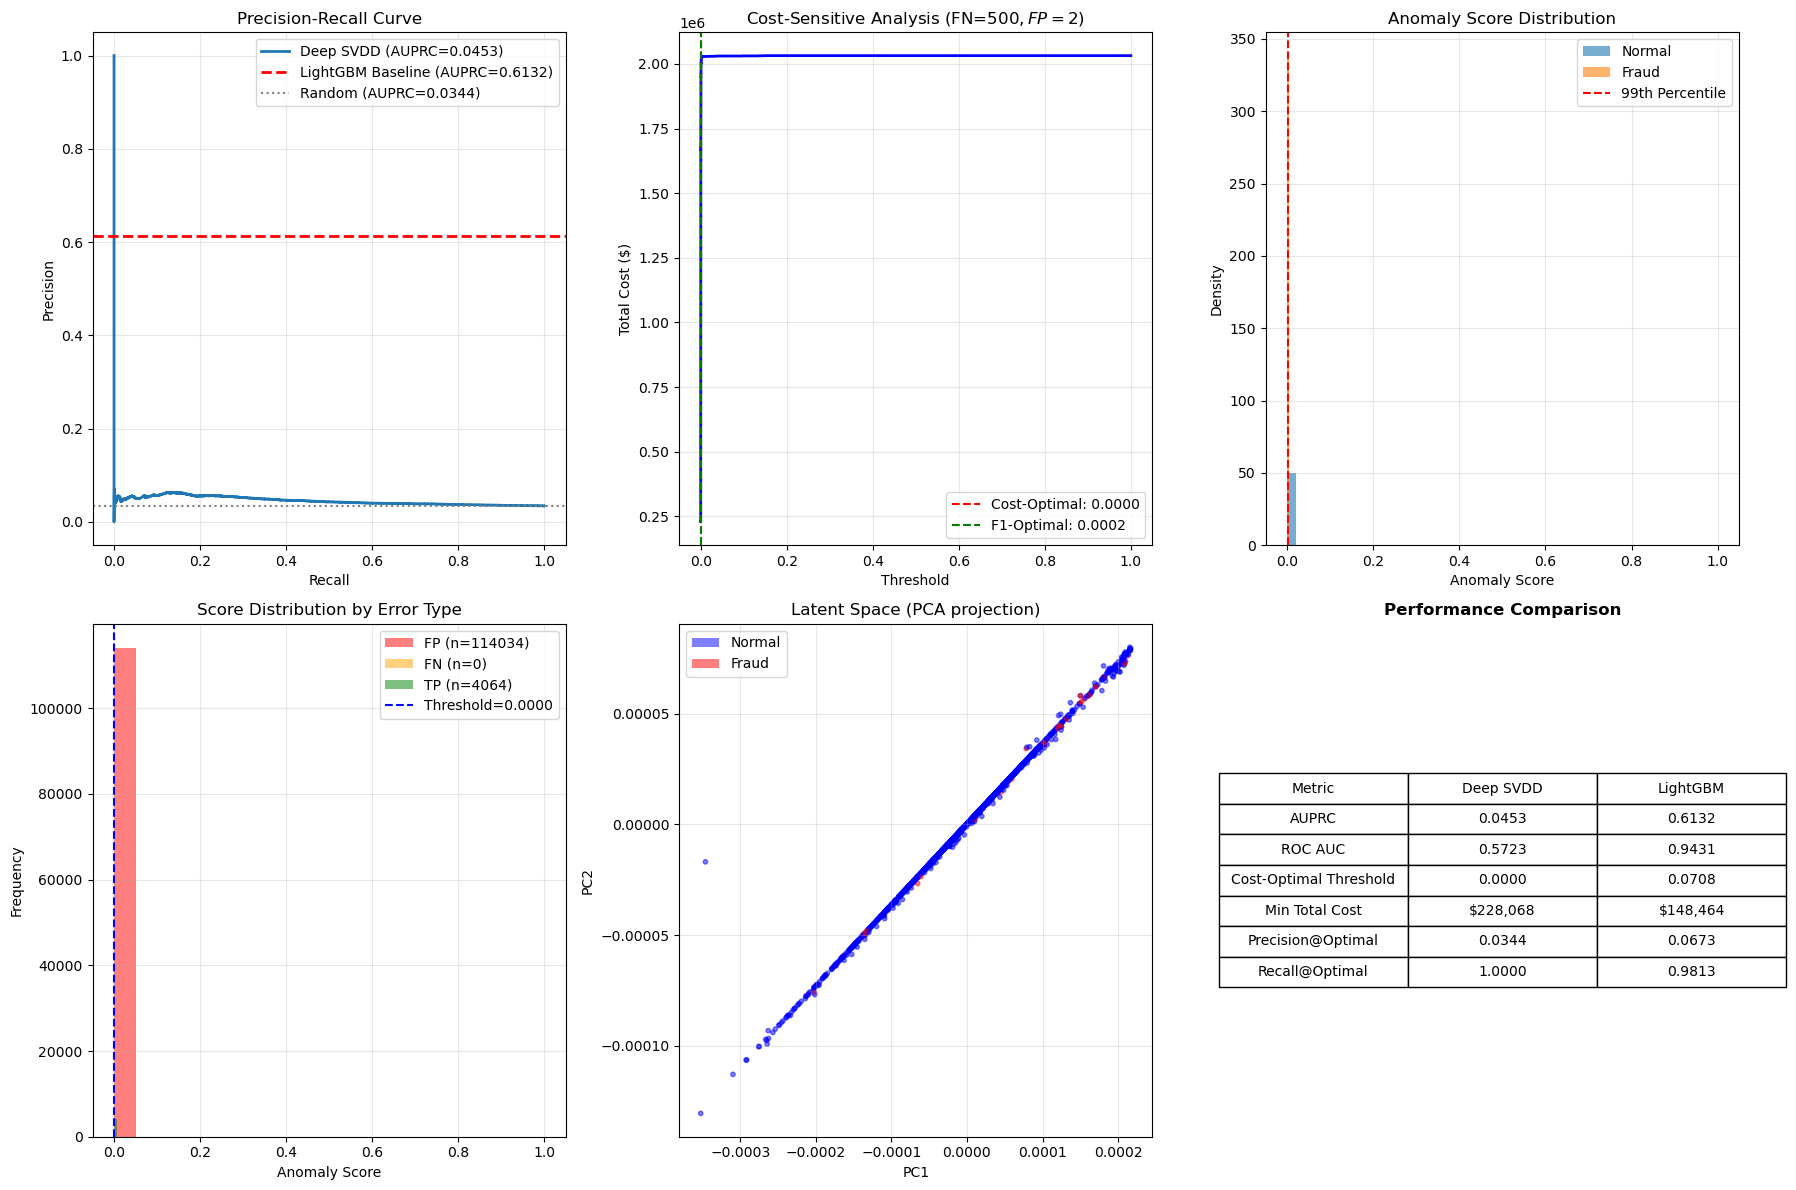

In [8]:
# 8. Visualization (2x3 subplots)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 8.1 PR Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_scores)
axes[0, 0].plot(recall_curve, precision_curve, linewidth=2, 
                label=f'Deep SVDD (AUPRC={auprc:.4f})')
axes[0, 0].axhline(y=0.6132, color='red', linestyle='--', linewidth=2,
                   label=f'LightGBM Baseline (AUPRC=0.6132)')
axes[0, 0].axhline(y=y_test.mean(), color='gray', linestyle=':', linewidth=1.5,
                   label=f'Random (AUPRC={y_test.mean():.4f})')
axes[0, 0].set_xlabel('Recall')
axes[0, 0].set_ylabel('Precision')
axes[0, 0].set_title('Precision-Recall Curve')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# 8.2 Cost Curve
axes[0, 1].plot(thresholds, costs, 'b-', linewidth=2)
axes[0, 1].axvline(x=cost_threshold, color='red', linestyle='--', 
                   label=f'Cost-Optimal: {cost_threshold:.4f}')
axes[0, 1].axvline(x=f1_threshold, color='green', linestyle='--', 
                   label=f'F1-Optimal: {f1_threshold:.4f}')
axes[0, 1].set_xlabel('Threshold')
axes[0, 1].set_ylabel('Total Cost ($)')
axes[0, 1].set_title('Cost-Sensitive Analysis (FN=$500, FP=$2)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 8.3 Anomaly Score Distribution
axes[0, 2].hist(test_scores[y_test==0], bins=50, alpha=0.6, label='Normal', density=True)
axes[0, 2].hist(test_scores[y_test==1], bins=50, alpha=0.6, label='Fraud', density=True)
threshold_99 = np.percentile(test_scores[y_test==0], 99)
axes[0, 2].axvline(x=threshold_99, color='red', linestyle='--', label=f'99th Percentile')
axes[0, 2].set_xlabel('Anomaly Score')
axes[0, 2].set_ylabel('Density')
axes[0, 2].set_title('Anomaly Score Distribution')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 8.4 Error Analysis - Score Distribution
fp_scores = test_scores[fp_idx] if len(fp_idx) > 0 else []
fn_scores = test_scores[fn_idx] if len(fn_idx) > 0 else []
tp_scores = test_scores[tp_idx] if len(tp_idx) > 0 else []

axes[1, 0].hist(fp_scores, bins=20, alpha=0.5, label=f'FP (n={len(fp_idx)})', color='red')
axes[1, 0].hist(fn_scores, bins=20, alpha=0.5, label=f'FN (n={len(fn_idx)})', color='orange')
axes[1, 0].hist(tp_scores, bins=20, alpha=0.5, label=f'TP (n={len(tp_idx)})', color='green')
axes[1, 0].axvline(x=cost_threshold, color='blue', linestyle='--', 
                   label=f'Threshold={cost_threshold:.4f}')
axes[1, 0].set_xlabel('Anomaly Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Score Distribution by Error Type')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 8.5 Latent Space Visualization
colors = ['blue' if y == 0 else 'red' for y in y_sample]
axes[1, 1].scatter(latent_2d[:, 0], latent_2d[:, 1], c=colors, alpha=0.5, s=10)
axes[1, 1].set_xlabel('PC1')
axes[1, 1].set_ylabel('PC2')
axes[1, 1].set_title('Latent Space (PCA projection)')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', alpha=0.5, label='Normal'),
                   Patch(facecolor='red', alpha=0.5, label='Fraud')]
axes[1, 1].legend(handles=legend_elements)
axes[1, 1].grid(True, alpha=0.3)

# 8.6 Results Summary Table
ax_table = axes[1, 2]
ax_table.axis('off')
table_data = [
    ['Metric', 'Deep SVDD', 'LightGBM'],
    ['AUPRC', f'{auprc:.4f}', '0.6132'],
    ['ROC AUC', f'{roc_auc:.4f}', '0.9431'],
    ['Cost-Optimal Threshold', f'{cost_threshold:.4f}', '0.0708'],
    ['Min Total Cost', f'${min_cost:,.0f}', '$148,464'],
    ['Precision@Optimal', f'{precision_opt:.4f}', '0.0673'],
    ['Recall@Optimal', f'{recall_opt:.4f}', '0.9813']
]
table = ax_table.table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
ax_table.set_title('Performance Comparison', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed' / 'deep_svdd_complete_results.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
# 9. Results Summary

results_summary = pd.DataFrame({
    'Model': [
        'Deep SVDD',
        'Semi-supervised Autoencoder',
        'Semi-supervised VAE',
        'Supervised Neural Network',
        'LightGBM Baseline'
    ],
    'AUPRC': [
        auprc,
        0.0702,
        0.0518,
        0.4887,
        0.6132
    ],
    'ROC AUC': [
        roc_auc,
        0.6286,
        0.6245,
        0.9046,
        0.9431
    ],
    'Cost-Optimal Threshold': [
        f"{cost_threshold:.4f}",
        "0.0006",
        "0.0003",
        "0.0789",
        "0.0708"
    ],
    'Min Total Cost': [
        f"${min_cost:,.2f}",
        "$227,974",
        "$228,050",
        "$190,470",
        "$148,464"
    ]
})

print("\n" + "="*80)
print("COMPLETE RESULTS SUMMARY - Deep SVDD vs All Models")
print("="*80)
print(results_summary.to_string(index=False))



COMPLETE RESULTS SUMMARY - Deep SVDD vs All Models
                      Model    AUPRC  ROC AUC Cost-Optimal Threshold Min Total Cost
                  Deep SVDD 0.045251 0.572303                 0.0000    $228,068.00
Semi-supervised Autoencoder 0.070200 0.628600                 0.0006       $227,974
        Semi-supervised VAE 0.051800 0.624500                 0.0003       $228,050
  Supervised Neural Network 0.488700 0.904600                 0.0789       $190,470
          LightGBM Baseline 0.613200 0.943100                 0.0708       $148,464
